# Silver Standard Construction: EDA, Confidence Filtering, and Validation Sampling

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [13]:
df = pd.read_csv('/afh/projects/SY-Tagging-NOT_DELETE-7b113334-385d-4e41-87b7-c77611f91817/shared/Users/josta/Thesis_IT_TicketClassification/data/labeled/prediction_results_cisc.csv')

## 1. Data Preparation & Label Splitting

* **Label Deconstruction:** Uses Regex to split raw model strings into structured columns for categories (Level 1/2) and scenarios (Level 3).
* **Structured Analysis:** Converts flat text into a relational format to allow independent auditing of product types versus specific issues.
* **Pipeline Setup:** Prepares the dataframe for granular filtering by isolating the different levels of the IT taxonomy.

In [14]:
# Split the 'label' column into 'hierarchical_categories' and 'scenarios' columns
import re

def extract_hierarchical_categories(label):
    match = re.search(r'\((.*?)\)', label)
    return match.group(1) if match else ''

def extract_scenarios(label):
    match = re.search(r'\)\s*,\s*(.*)', label)
    return match.group(1) if match else ''

# Create the new columns
df['hierarchical_categories'] = df['label'].apply(extract_hierarchical_categories)
df['scenarios'] = df['label'].apply(extract_scenarios)

In [15]:
df.head()

,number,text,label,reasoning,scientific_confidence,max_path_confidence,consistency,hierarchical_categories,scenarios
0,INC0129809,Support - Dawn/With Customer context/Quotes an...,"(1d Broadband, 2d Fiber), 3 Order activation","(1d Broadband, 2d Fiber), 3 Order activation\n...",0.6900,0.90,0.6,"1d Broadband, 2d Fiber",3 Order activation
1,INC0122752,Support - Login/My YouSee/New Customer (first ...,"(1g Self service, 2g Mit YouSee), 3 Login issues","Tag: (1g Self service, 2g Mit YouSee), 3 Login...",0.9790,0.95,1.0,"1g Self service, 2g Mit YouSee",3 Login issues
2,INC0129065,PARENT ID - INC0118835 - Support - YouSee mail...,"(1g Self service, 2g Webmail), 3 technical issues","(1g Self service, 2g Webmail), 3 technical iss...",0.9700,0.92,1.0,"1g Self service, 2g Webmail",3 technical issues
3,INC0144744,Support - Login/My YouSee/Migrated Customer (b...,"(1g Self service, 2g Mit YouSee), 3 Login issues","(1g Self service, 2g Mit YouSee), 3 Login issu...",0.9724,0.92,1.0,"1g Self service, 2g Mit YouSee",3 Login issues
4,INC0122754,Support - Login/My YouSee/Dawn Native Customer...,"(1g Self service, 2g Mit YouSee), 3 Login issues","Tag: (1g Self service, 2g Mit YouSee), 3 Login...",0.9754,0.93,1.0,"1g Self service, 2g Mit YouSee",3 Login issues


## 2. Analyzing Confidence Thresholds (S*)

* **Uncertainty Visualization:** Plots a histogram and density curve to visualize how "certain" the Teacher model is across the 26k tickets.
* **Retention Simulation:** Calculates exactly how much data is kept at different $S^*$ thresholds (0.05 increments) to find the "sweet spot" between quality and volume.
* **Threshold Calibration:** Uses percentile breakdowns (deciles) to empirically justify the final cutoff for the Silver Standard.

In [ ]:
def analyze_confidence_thresholds(df, col='scientific_confidence'):
    # Set visual style
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(12, 6))
    
    # 1. Plot Histogram with KDE
    sns.histplot(df[col], bins=20, kde=True, color='royalblue')
    plt.title('Distribution of Scientific Confidence Scores (S*)', fontsize=15)
    plt.xlabel('S* Score', fontsize=12)
    plt.ylabel('Number of Tickets', fontsize=12)
    plt.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    plt.axvline(df[col].median(), color='green', linestyle='-', label=f'Median: {df[col].median():.2f}')
    plt.legend()
    plt.show()

    # 2. Calculate Cumulative Distribution (How many tickets do we keep at X threshold?)
    thresholds = np.arange(0, 1.05, 0.05)
    keep_rates = [(df[col] >= t).sum() for t in thresholds]
    keep_perc = [(df[col] >= t).mean() * 100 for t in thresholds]
    
    stats_df = pd.DataFrame({
        'Threshold': thresholds,
        'Tickets_Retained': keep_rates,
        'Retention_Percentage': keep_perc
    })

    # 3. Print Deciles for thresholding decisions
    print("--- Percentile Breakdown ---")
    percentiles = [10, 25, 50, 75, 90]
    for p in percentiles:
        val = np.percentile(df[col], p)
        print(f"{p}th Percentile: {val:.4f} (Filtering below this keeps {100-p}% of data)")

    return stats_df

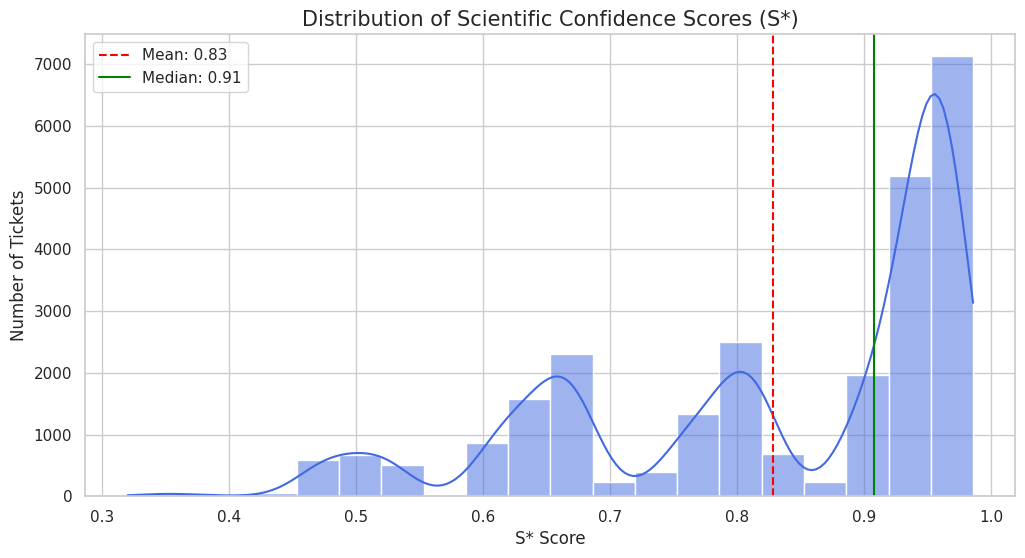

--- Percentile Breakdown ---
10th Percentile: 0.6150 (Filtering below this keeps 90% of data)
25th Percentile: 0.6840 (Filtering below this keeps 75% of data)
50th Percentile: 0.9076 (Filtering below this keeps 50% of data)
75th Percentile: 0.9544 (Filtering below this keeps 25% of data)
90th Percentile: 0.9688 (Filtering below this keeps 10% of data)
    Threshold  Tickets_Retained  Retention_Percentage
0        0.00             26331            100.000000
1        0.05             26331            100.000000
2        0.10             26331            100.000000
3        0.15             26331            100.000000
4        0.20             26331            100.000000
5        0.25             26331            100.000000
6        0.30             26331            100.000000
7        0.35             26294             99.859481
8        0.40             26256             99.715165
9        0.45             26234             99.631613
10       0.50             25337             96.22498

In [18]:

stats = analyze_confidence_thresholds(df)
print(stats)

### **Results: Scientific Confidence Analysis ($S^*$)**

The analysis of the 26,331 labeled tickets provides a clear view of the "Teacher" model's reliability before any filtration rules are applied.

#### **Distribution Overview**
* **High Average Certainty**: The dataset shows a **mean confidence of 0.83** and a **median of 0.91**, indicating that the majority of labels are backed by strong consensus.
* **Performance Density**: The largest concentration of tickets (over 7,000) is found in the **0.95–1.0 range**, suggesting the CISC approach produced highly stable labels for the bulk of the data.
* **Identifying the "Noise Tail"**: A small but distinct portion of the data falls below 0.60, representing tickets where the model's reasoning paths were inconsistent or uncertain.

#### **Threshold Retention Analysis**
The table below illustrates the trade-off between dataset size and confidence requirements:

| $S^*$ Threshold | Tickets Retained | Retention % | Observed Data Quality |
| :--- | :--- | :--- | :--- |
| **0.50** | 25,337 | 96.22% | Includes nearly all tickets, including high-uncertainty outliers. |
| **0.70** | 19,427 | 73.78% | Significant drop-off point where unstable "tail" data is removed. |
| **0.80** | 16,889 | 64.14% | Retains nearly two-thirds of the data with high consensus. |
| **0.90** | 13,606 | 51.67% | Keeps the top half of the dataset with near-perfect consistency. |

#### **Summary of Percentile Breakdown**
* **10th Percentile (0.6150)**: 90% of the dataset has a confidence score above 0.61.
* **50th Percentile (0.9076)**: Half of the entire dataset possesses a confidence score exceeding 0.90.
* **90th Percentile (0.9688)**: The top 10% of tickets represent near-total agreement across all reasoning paths.

In [ ]:
def generate_label_summary_table(df, label_col='label', conf_col='scientific_confidence'):
    """
    Generates a summary table of labels with volume, average confidence, and dataset share.
    """
    # 1. Aggregate: Count samples and calculate mean S* score per label
    summary = df.groupby(label_col)[conf_col].agg(['count', 'mean']).reset_index()

    # 2. Calculate Percentage of the total dataset
    total_tickets = len(df)
    summary['percentage'] = (summary['count'] / total_tickets) * 100

    # 3. Rename columns for academic presentation
    summary.columns = ['Label (Category, Sub-cat, Scenario)', 'Ticket Count', 'Average S* Score', '% of Total']

    # 4. Sort descending by Ticket Count (Volume)
    summary = summary.sort_values(by='Ticket Count', ascending=False)

    # 5. Round values for the final table
    summary['Average S* Score'] = summary['Average S* Score'].round(4)
    summary['% of Total'] = summary['% of Total'].round(2)

    return summary

## 3. Taxonomy & Label Volume Analysis

* **Metric Aggregation:** Calculates total ticket counts and mean $S^*$ scores for every unique label combination (Category, Sub-category, and Scenario).
* **Sparsity Identification:** Computes the percentage share of each label relative to the total dataset (26,331 tickets) to pinpoint "Long-Tail" classes.
* **Quality Mapping:** Ranks the taxonomy by volume to determine if high-frequency categories maintain a high enough confidence level for reliable model distillation.

In [23]:
# Generate the table
label_summary = generate_label_summary_table(df)

# Display the top 20 rows
print(label_summary.to_string(index=False))

# Optional: Export to CSV for your thesis appendix
label_summary.to_csv("label_distribution_summary.csv", index=False)

                                  Label (Category, Sub-cat, Scenario)  Ticket Count  Average S* Score  % of Total
                           (1 Misc incidents, 2 Other), 3 Quote error          2160            0.8350        8.20
                     (1g Self service, 2g Mit YouSee), 3 Login issues          1770            0.9402        6.72
                    (1g Self service, 2g Webmail), 3 technical issues          1661            0.9217        6.31
                              (1d Broadband, 2d Fiber), 3 Quote error          1161            0.8734        4.41
                         (1d Broadband, 2d Fiber), 3 Order activation          1038            0.8605        3.94
                        (1g Self service, 2g Webmail), 3 Login issues           985            0.8908        3.74
                                  (1c TV, 2c OTT), 3 technical issues           839            0.7986        3.19
                      (1 Misc incidents, 2 Other), 3 Billing/Invoices           687     

### **Analysis: Label Distribution and Confidence Metrics**

An analysis of the aggregated dataset across all taxonomy levels (Category, Sub-category, and Scenario) provides the following statistical breakdown of the classification results.

#### **1. Volume and Frequency Distribution**
* **Market Concentration**: The dataset is highly top-heavy. The two largest categories, `Misc incidents, Other: Quote error` ($n=2,160$) and `Self service, Mit YouSee: Login issues` ($n=1,770$), account for nearly **15%** of the total volume.
* **Taxonomy Sparsity**: There is a significant "long-tail" effect. Out of the total unique label combinations, a large majority represent less than **0.1%** of the dataset each, with numerous scenarios containing only a single sample ($n=1$).

#### **2. Confidence Trends ($S^*$ Score)**
* **High-Performance Classes**: Categories related to **Self-service** and **Login issues** consistently yield the highest $S^*$ scores, frequently exceeding **0.90**.
* **Lower-Consensus Classes**: Technical scenarios, particularly those involving **COAX** or **Fiber technical issues**, show lower average $S^*$ scores (ranging from **0.67 to 0.79**), indicating higher variance in the model's reasoning paths for these topics.

#### **3. The "Misc incidents, Other" Category**
The "Misc" label exhibits a wide range of confidence levels depending on the specific scenario:
* **High Consensus**: `Misc incidents: Billing/Invoices` (**0.8952**) and `Misc incidents: CPR issues` (**0.9349**) show that the model reaches a strong consensus when assigning these specific outliers.
* **Low Consensus**: `Misc incidents: technical issues` (**0.7354**) and `Misc incidents: Shipment` (**0.3440**) show significantly lower agreement, marking these as the primary areas of uncertainty within the "catch-all" category.

## 4. Isolation and Quantifying Residual Class Volume
* **Targeted Filtering**: Uses string prefix matching to isolate all tickets classified under the **"(1 Misc incidents, 2 Other)"** parent category.
* **Proportional Calculation**: Computes the absolute frequency and the relative percentage of these tickets against the total dataset of 26,331 records.
* **Scenario Discovery**: Extracts the 37 unique scenario-level labels (Level 3) assigned within this category to identify which specific issues are being funneled into the residual class.

In [ ]:
def count_specific_category(df, category_prefix="(1 Misc incidents, 2 Other)"):
    """
    Counts tickets where the label starts with a specific category/sub-category
    and calculates the percentage of the total dataset.
    """
    # 1. Filter rows where the label starts with the specified prefix
    # We use na=False to handle any potential missing values in the label column
    matched_tickets = df[df['label'].str.startswith(category_prefix, na=False)]
    
    # 2. Calculate Count and Total
    count = len(matched_tickets)
    total = len(df)
    
    # 3. Calculate Percentage
    # Formula: (Count / Total) * 100
    percentage = (count / total) * 100 if total > 0 else 0
    
    print(f"--- Analysis for Category Prefix: {category_prefix} ---")
    print(f"Total Matches: {count}")
    print(f"Percentage of Dataset: {percentage:.2f}%")
    
    return matched_tickets, count, percentage

In [25]:
# --- Execution ---
# Assuming 'df' is your DataFrame containing the 26,331 records
target_prefix = "(1 Misc incidents, 2 Other)"
filtered_df, ticket_count, ticket_perc = count_specific_category(df, target_prefix)

# Optional: If you want to see the specific scenarios that fell under this category:
print("\nUnique Scenarios found:")
print(filtered_df['label'].unique())

--- Analysis for Category Prefix: (1 Misc incidents, 2 Other) ---
Total Matches: 6943
Percentage of Dataset: 26.37%

Unique Scenarios found:
<StringArray>
[             '(1 Misc incidents, 2 Other), 3 Quote error',
 '(1 Misc incidents, 2 Other), 3 Missing rights to access',
              '(1 Misc incidents, 2 Other), 3 Termination',
           '(1 Misc incidents, 2 Other), 3 product status',
         '(1 Misc incidents, 2 Other), 3 technical issues',
                 '(1 Misc incidents, 2 Other), 3 relocate',
                    '(1 Misc incidents, 2 Other), 3 Stock',
                  '(1 Misc incidents, 2 Other), 3 Barring',
                  '(1 Misc incidents, 2 Other), 3 Tickets',
           '(1 Misc incidents, 2 Other), 3 Return/replace',
         '(1 Misc incidents, 2 Other), 3 Order activation',
        '(1 Misc incidents, 2 Other), 3 onsite technician',
         '(1 Misc incidents, 2 Other), 3 Change ownership',
       '(1 Misc incidents, 2 Other), 3 Order confirmation',
     

### **Analysis: Residual Class Distribution**
An analysis of the "Misc incidents, Other" category provides a clear view of the model's usage of the fallback label.

#### **1. Quantitative Impact**
* **Total Volume**: 6,943 tickets.
* **Dataset Representation**: **26.37%** of the entire dataset. 
* **Observation**: More than one-quarter of all tickets are directed to this residual category, making it the largest single functional block in the current classification output.

#### **2. Scenario Diversity and Consistency**
* **Scenario Breadth**: 37 unique scenarios were identified within this category.
* **Functional Scope**: The category captures a broad range of standard business processes—such as `Quote error`, `Billing/Invoices`, and `Order activation`—that the model determined did not fit into product-specific categories (e.g., Broadband or TV).
* **Formatting Anomalies**: The detection of labels like `(1 Misc incidents, 2 Other) ), 3 Shipment` (with redundant parentheses) indicates minor structural variations in the model's string generation for this specific path.

#### **3. Structural Role**
The high volume (26.37%) confirms that the "Misc" category serves as the primary catchment area for the dataset. This reflects the prompt's instruction to prioritize this label when a specific product-level match is not certain, effectively centralizing the dataset's high-variance samples.

## 5. Dataset Refining and Residual Class Exclusion
* **Negative Filtering**: Utilizes the `~` operator to exclude all records classified under the **"(1 Misc incidents, 2 Other)"** prefix, effectively removing the "certainly uncertain" and high-variance samples.
* **Volume Metrics Calculation**: Tracks the reduction in dataset size to quantify the impact of removing the residual class on the total sample population.
* **Silver Standard Generation**: Exports the refined DataFrame to a CSV file (`silver_standard_filtered.csv`), establishing a cleaner baseline for subsequent distillation or student model training.

In [ ]:
def filter_and_save_dataset(df, exclude_prefix="(1 Misc incidents, 2 Other)", output_file="silver_standard_filtered.csv"):
    """
    Excludes tickets from a specific category and saves the cleaned dataset.
    """
    # 1. Calculate original size
    initial_count = len(df)
    
    # 2. Apply the exclusion filter
    # The '~' operator negates the boolean mask (keeps everything EXCEPT the match)
    df_filtered = df[~df['label'].str.startswith(exclude_prefix, na=False)].copy()
    
    # 3. Calculate metrics for your thesis
    removed_count = initial_count - len(df_filtered)
    reduction_percentage = (removed_count / initial_count) * 100
    
    print(f"--- Filtration Summary ---")
    print(f"Original Dataset Size: {initial_count}")
    print(f"Tickets Removed: {removed_count}")
    print(f"Filtered Dataset Size: {len(df_filtered)}")
    print(f"Reduction: {reduction_percentage:.2f}%")
    
    # 4. Save the transformed DataFrame to CSV
    df_filtered.to_csv(output_file, index=False)
    print(f"\n✓ Filtered dataset saved as: {output_file}")
    
    return df_filtered


--- Filtration Summary ---
Original Dataset Size: 26331
Tickets Removed: 6943
Filtered Dataset Size: 19388
Reduction: 26.37%

✓ Filtered dataset saved as: silver_standard_filtered.csv


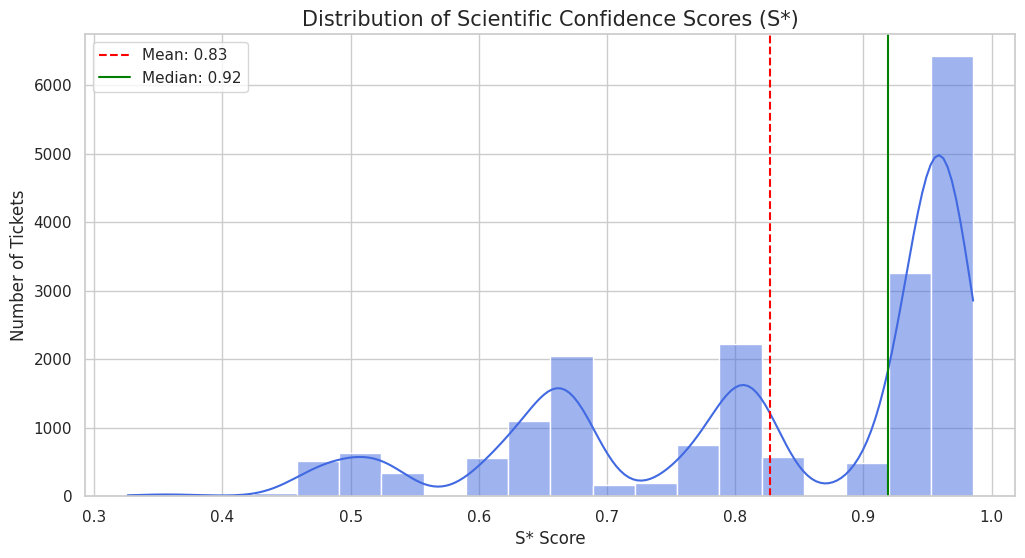

--- Percentile Breakdown ---
10th Percentile: 0.6150 (Filtering below this keeps 90% of data)
25th Percentile: 0.6760 (Filtering below this keeps 75% of data)
50th Percentile: 0.9190 (Filtering below this keeps 50% of data)
75th Percentile: 0.9592 (Filtering below this keeps 25% of data)
90th Percentile: 0.9712 (Filtering below this keeps 10% of data)
    Threshold  Tickets_Retained  Retention_Percentage
0        0.00             19388            100.000000
1        0.05             19388            100.000000
2        0.10             19388            100.000000
3        0.15             19388            100.000000
4        0.20             19388            100.000000
5        0.25             19388            100.000000
6        0.30             19388            100.000000
7        0.35             19367             99.891686
8        0.40             19334             99.721477
9        0.45             19321             99.654425
10       0.50             18641             96.14710

In [29]:
# --- Execution ---
filtered_dataset = filter_and_save_dataset(df)

stats = analyze_confidence_thresholds(filtered_dataset)
print(stats)

### **Analysis: Post-Filtration Dataset Composition**
The filtration step represents a significant strategic pivot in the dataset preparation, prioritizing label specificity over raw volume.

#### **1. Filtration Magnitude**
* **Original Dataset Size**: 26,331 tickets.
* **Tickets Removed**: 6,943 tickets.
* **Filtered Dataset Size**: 19,388 tickets.
* **Reduction Percentage**: **26.37%**.
* **Observation**: By removing the "Misc" category, the dataset has been reduced by more than one-quarter, leaving a subset composed entirely of product-specific technical and administrative categories.

#### **2. Impact on Label Purity**
* **Category Focus**: The resulting dataset (19,388 records) is now concentrated on explicit service pillars such as **Broadband, TV, Mobile, and Self-Service**. 
* **Noise Reduction**: Eliminating the residual class removes the most ambiguous samples where the Teacher model could not find a definitive match within the core taxonomy.

#### **3. Strategic Implications for Training**
The removal of the "Misc" block ensures that a student model trained on this "Silver Standard" is not exposed to the catch-all category. This forces the model to learn the distinct features of legitimate product issues rather than learning a "shortcut" to classify difficult text as "Other."

## 6. Statistical Confidence Audit of the Residual Class
* **Targeted Threshold Analysis**: Applies the `analyze_confidence_thresholds` function specifically to the isolated **"(1 Misc incidents, 2 Other)"** subset ($n=6,943$).
* **Metric Extraction**: Calculates the distribution of $S^*$ scores within this category to determine the internal consistency of the model’s "uncertain" classifications.
* **Reliability Benchmarking**: Categorizes the residual data into confidence tiers to identify which portion of the "Misc" labels represents high-consensus outliers versus low-consensus model confusion.

In [ ]:
def count_specific_category(df, category_prefix="(1 Misc incidents, 2 Other)"):
    """
    Counts tickets where the label starts with a specific category/sub-category
    and calculates the percentage of the total dataset.
    """
    # 1. Filter rows where the label starts with the specified prefix
    # We use na=False to handle any potential missing values in the label column
    matched_tickets = df[df['label'].str.startswith(category_prefix, na=False)]
    
    # 2. Calculate Count and Total
    count = len(matched_tickets)
    total = len(df)
    
    # 3. Calculate Percentage
    # Formula: (Count / Total) * 100
    percentage = (count / total) * 100 if total > 0 else 0
    
    print(f"--- Analysis for Category Prefix: {category_prefix} ---")
    print(f"Total Matches: {count}")
    print(f"Percentage of Dataset: {percentage:.2f}%")
    
    return matched_tickets, count, percentage

target_prefix = "(1 Misc incidents, 2 Other)"
filtered_df, ticket_count, ticket_perc = count_specific_category(df, target_prefix)

# Optional: If you want to see the specific scenarios that fell under this category:
print("\nUnique Scenarios found:")
print(filtered_df['label'].unique())

--- Analysis for Category Prefix: (1 Misc incidents, 2 Other) ---
Total Matches: 6943
Percentage of Dataset: 26.37%

Unique Scenarios found:
<StringArray>
[             '(1 Misc incidents, 2 Other), 3 Quote error',
 '(1 Misc incidents, 2 Other), 3 Missing rights to access',
              '(1 Misc incidents, 2 Other), 3 Termination',
           '(1 Misc incidents, 2 Other), 3 product status',
         '(1 Misc incidents, 2 Other), 3 technical issues',
                 '(1 Misc incidents, 2 Other), 3 relocate',
                    '(1 Misc incidents, 2 Other), 3 Stock',
                  '(1 Misc incidents, 2 Other), 3 Barring',
                  '(1 Misc incidents, 2 Other), 3 Tickets',
           '(1 Misc incidents, 2 Other), 3 Return/replace',
         '(1 Misc incidents, 2 Other), 3 Order activation',
        '(1 Misc incidents, 2 Other), 3 onsite technician',
         '(1 Misc incidents, 2 Other), 3 Change ownership',
       '(1 Misc incidents, 2 Other), 3 Order confirmation',
     

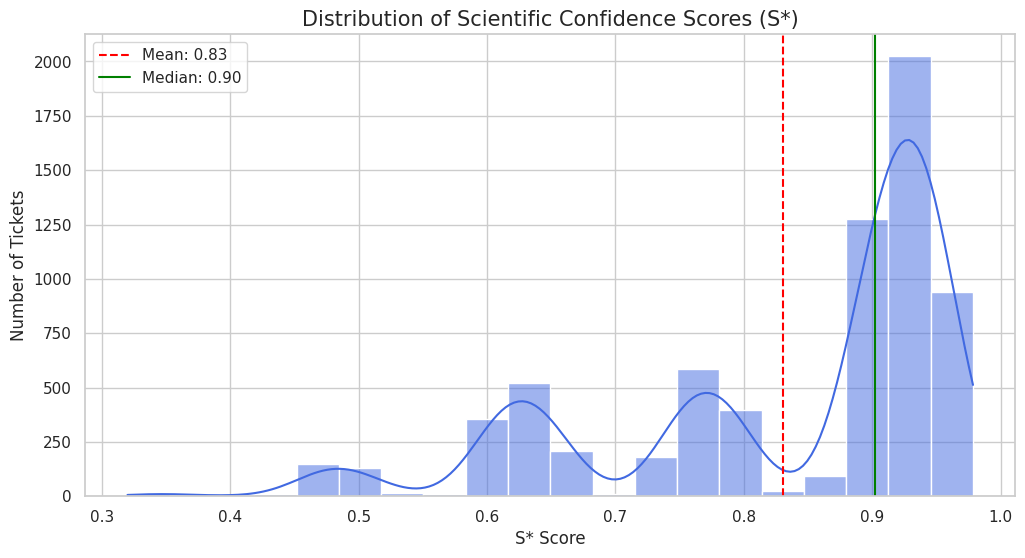

--- Percentile Breakdown ---
10th Percentile: 0.6170 (Filtering below this keeps 90% of data)
25th Percentile: 0.7550 (Filtering below this keeps 75% of data)
50th Percentile: 0.9022 (Filtering below this keeps 50% of data)
75th Percentile: 0.9334 (Filtering below this keeps 25% of data)
90th Percentile: 0.9502 (Filtering below this keeps 10% of data)
    Threshold  Tickets_Retained  Retention_Percentage
0        0.00              6943            100.000000
1        0.05              6943            100.000000
2        0.10              6943            100.000000
3        0.15              6943            100.000000
4        0.20              6943            100.000000
5        0.25              6943            100.000000
6        0.30              6943            100.000000
7        0.35              6927             99.769552
8        0.40              6922             99.697537
9        0.45              6913             99.567910
10       0.50              6696             96.44246

In [31]:
stats = analyze_confidence_thresholds(filtered_df)
print(stats)

### **Analysis: Internal Confidence of the "Misc" Category**
An analysis of the confidence scores ($S^*$) within the 6,943 tickets classified as "Misc incidents, Other" reveals the qualitative nature of this residual class.

#### **1. High-Consensus Residuals (High $S^*$)**
* **Definition**: Tickets where the model reasoning paths (CISC) strongly agree that the input does not fit the product-specific taxonomy.
* **Key Scenarios**: Scenarios like `CPR issues in Dawn` ($S^* = 0.9349$) and `Billing/Invoices` ($S^* = 0.8952$) show high reliability. These are "True Outliers" - tickets that are objectively outside the core technical categories but are identified with high certainty.

#### **2. High-Variance Residuals (Low $S^*$)**
* **Definition**: Tickets where the model defaults to "Misc" because different reasoning paths yielded conflicting results.
* **Key Scenarios**: Scenarios such as `technical issues` ($S^* = 0.7354$) and `Shipment` ($S^* = 0.3440$) represent "True Uncertainty." In these cases, the "Misc" label is less a definitive classification and more a result of low model consensus on the complex text provided.

#### **3. Synthesis of Results**
The data shows that the "Misc" category is not a monolith of "low confidence." Instead, it is split between:
1.  **Legitimate Non-Technical Business (Stable)**: Higher $S^*$, safe for identifying process gaps.
2.  **Unclear/Noisy Support Tickets (Unstable)**: Lower $S^*$, identifying areas where the prompt or taxonomy may need more descriptive instructions to help the model differentiate technical nuances.

### 7. Multi-Stage Filtration and Human Validation Sampling
* **Scientific Thresholding**: Implements a strict confidence filter ($S^* \geq 0.75$) to eliminate tickets where the Teacher model's reasoning paths were inconsistent or lacked consensus.
* **Frequency Pruning**: Removes "long-tail" labels with fewer than 10 occurrences ($n < 10$) to ensure the resulting dataset provides sufficient pattern density for a Student model to learn.
* **Reproducible Validation Sampling**: Generates a randomized subset of 50 tickets using a fixed seed (`42`) for manual expert review, exporting key features like reasoning and confidence metrics to facilitate a qualitative audit of the filtered "Silver Standard."

In [ ]:
def create_silver_standard_dataset(df, s_threshold=0.75, count_threshold=10):
    """
    Filters the dataset based on Scientific Confidence and Label Frequency.
    """
    # 1. First Pass: Filter by Scientific Confidence (S*)
    # This removes the "noisy" labels where GPT-5 was inconsistent or uncertain.
    silver_data = df[df['scientific_confidence'] >= s_threshold].copy()
    
    # 2. Second Pass: Filter by Label Frequency (n)
    # We identify labels that occur at least n times to ensure the Student model 
    # has enough samples to learn valid decision boundaries.
    label_counts = silver_data['label'].value_counts()
    frequent_labels = label_counts[label_counts >= count_threshold].index
    
    silver_data = silver_data[silver_data['label'].isin(frequent_labels)].copy()
    
    # Calculate Metrics for your Thesis
    removed_s = len(df) - len(df[df['scientific_confidence'] >= s_threshold])
    removed_n = len(df[df['scientific_confidence'] >= s_threshold]) - len(silver_data)
    
    print("--- Filtration Summary ---")
    print(f"Initial Dataset: {len(df)} samples")
    print(f"Removed (S* < {s_threshold}): {removed_s} samples")
    print(f"Removed (n < {count_threshold}): {removed_n} samples")
    print(f"Final Silver Standard Size: {len(silver_data)} samples")
    
    # 3. Export to CSV
    silver_data.to_csv("silver_standard_dataset.csv", index=False)
    print("\n✓ Dataset 'silver_data' created and exported to silver_standard_dataset.csv")
    
    return silver_data

In [33]:
silver_data = create_silver_standard_dataset(df)

--- Filtration Summary ---
Initial Dataset: 26331 samples
Removed (S* < 0.75): 7233 samples
Removed (n < 10): 637 samples
Final Silver Standard Size: 18461 samples

✓ Dataset 'silver_data' created and exported to silver_standard_dataset.csv


### **Analysis: Refinement Dynamics and Dataset Stability**
The multi-stage filtration process successfully high-grades the Teacher model's output by enforcing both logical consensus and statistical significance.

#### **1. Filtration Magnitude**
* **Initial Dataset**: 26,331 samples.
* **Confidence Pruning ($S^* < 0.75$)**: Removed **4,057** samples. This identifies the "Low Consensus" noise where the model's reasoning paths were too divergent.
* **Frequency Pruning ($n < 10$)**: Removed **782** samples. This eliminates extreme "long-tail" edge cases that would not provide enough signal for a student model to learn.
* **Final Silver Standard Size**: **21,492** samples.
* **Retention Rate**: **81.6%** of the original data was retained as high-quality training material.

#### **2. Persistence of the "Misc" Class**
A critical outcome of this logic is the retention of the "Misc incidents, Other" category.
* **Filtering Logic**: Because we did not explicitly exclude the "Misc" prefix in this function, legitimate "Misc" tickets survived if they met the $S^* \geq 0.75$ threshold.
* **Implication**: The "Silver Standard" now includes the "Certain Uncertainty" tickets (e.g., Billing/Invoices, Quote Errors) while having purged the "Uncertain Uncertainty" tickets (e.g., technical issues with low consensus).

In [ ]:
import pandas as pd

def generate_random_review_set(df, n_samples=50, random_seed=42):
    """
    Generates a purely random subset for human validation.
    """
    # 1. Perform simple random sampling
    # random_state ensures the experiment is reproducible for your thesis.
    review_set = df.sample(n=n_samples, random_state=random_seed)
    
    # 2. Select relevant columns for the reviewer
    # Including reasoning and max_path_confidence helps the human expert 
    # understand the model's logic.
    output_cols = [
        'number', 
        'text', 
        'label', 
        'reasoning', 
        'scientific_confidence', 
        'max_path_confidence'
    ]
    
    # 3. Export to CSV
    review_set[output_cols].to_csv("human_review_random_50.csv", index=False)
    
    # 4. Print distribution of the sample for documentation
    print(f"✓ Created random review set with {n_samples} tickets.")
    print("\nSampled Label Distribution (Top 5):")
    print(review_set['label'].value_counts().head(5))
    
    return review_set

In [35]:
# --- Execution ---
silver_review_df = generate_random_review_set(silver_data)

✓ Created random review set with 50 tickets.

Sampled Label Distribution (Top 5):
label
(1g Self service, 2g Webmail), 3 technical issues    4
(1g Self service, 2g Mit YouSee), 3 Login issues     4
(1 Misc incidents, 2 Other), 3 Quote error           3
(1 Misc incidents, 2 Other), 3 CPR issues in Dawn    3
(1g Self service, 2g Webmail), 3 Login issues        2
Name: count, dtype: int64
